# TransE - Colab Implementation & Reproduction


### Translating Embeddings for Modeling Multi-relational Data (NeurIPS, 2013) 의 알고리즘을 파이썬 코드로 구현하고, Link prediction 실험의 성능을 재현한 코드

**구현 범위**
- Uniform 초기화 ($Unif(-6/\sqrt{k}, 6/\sqrt{k})$)
- 매 epoch마다 entity normalization
- Negative sampling (corrupted triplet, head 또는 tail 중 하나만 교체)
- Margin-based ranking loss
- Link prediction 평가 (raw / filtered, Mean Rank, Hits@10)

**데이터셋**: FB15k (https://huggingface.co/datasets/VLyb/FB15k)

## 1. Environment 

In [2]:
import torch
print("Torch version:", torch.__version__)
print("Cuda available:", torch.cuda.is_available())
device = torch.device("cuda") if torch.cuda.is_available() else ("cpu")
print("Using device:", device)

Torch version: 2.11.0+cu128
Cuda available: True
Using device: cuda


## 2. Download Dataset (FB15k) & Load Data

Dataset : FB15k

Dataset Download : https://huggingface.co/datasets/VLyb/FB15k

train/validation/test에서 각각 `head,relation,tail` 으로 구분 후 다시 `(h, r, t)` 튜플 형태로 합친 후, list 반환



In [3]:
from datasets import load_dataset

ds = load_dataset("VLyb/FB15k")

def hf_split_to_tuples(split):
    return list(zip(split["head"], split["relation"], split["tail"]))

train_raw = hf_split_to_tuples(ds["train"])
valid_raw = hf_split_to_tuples(ds["validation"])
test_raw  = hf_split_to_tuples(ds["test"])

print(f"Train : {len(train_raw)}")
print(f"Validation : {len(valid_raw)}")
print(f"Test : {len(test_raw)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/293 [00:00<?, ?B/s]

train.csv: reconstructing file:   0%|          |  0.00B / 37.6MB            

train.csv: downloading bytes:           |  0.00B            

valid.csv:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/4.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/483142 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/59071 [00:00<?, ? examples/s]

Train : 483142
Validation : 50000
Test : 59071


## 3. Build Entity / Relation Dictionary

In [4]:
# 엔티티/관계 dictionary(=엔티티 집합 'E') 구축
all_triples_raw = train_raw + valid_raw + test_raw
entities = sorted(set(h for h, r, t in all_triples_raw) | set(t for h, r, t in all_triples_raw))
relations = sorted(set(r for h, r, t in all_triples_raw))

ent2id = {e: i for i, e in enumerate(entities)}
rel2id = {r: i for i, r in enumerate(relations)}

n_ent, n_rel = len(entities), len(relations)
print(f"Number of Entities = {n_ent}, Number of Relations = {n_rel}")

def to_id(triples):
    return torch.tensor(
        [[ent2id[h], rel2id[r], ent2id[t]] for h, r, t in triples],
        dtype=torch.long
    )

train = to_id(train_raw)
valid = to_id(valid_raw)
test  = to_id(test_raw)
all_triples = set(map(tuple, torch.cat([train, valid, test], dim=0).tolist()))

print("train/valid/test:", train.shape, valid.shape, test.shape)
print("all triples:", len(all_triples), "(Remove duplicate triples)")


Number of Entities = 14951, Number of Relations = 1345
train/valid/test: torch.Size([483142, 3]) torch.Size([50000, 3]) torch.Size([59071, 3])
all triples: 592213 (Remove duplicate triples)


## 4. TransE 모델 구현
알고리즘:

1. **Initialization**: $Unif(-\frac{6}{\sqrt{k}}, \frac{6}{\sqrt{k}})$ 로 entity/relation 초기화, relation은 초기화 직후 normalize
2. **Loop**: 매 epoch마다 entity normalize → 미니배치 샘플링 → negative sampling → margin loss로 업데이트


In [5]:
import torch.nn as nn
import torch.nn.functional as F

class TransE(nn.Module):
    def __init__(self, n_entities, n_relations, k=50, margin=1.0, p_norm=1):
        super().__init__()
        self.k = k
        self.margin = margin
        self.p_norm = p_norm  # L1 norm 또는 L2 norm

        bound = 6 / (k ** 0.5)  # Unif(-6/sqrt(k), 6/sqrt(k))
        self.entity_emb = nn.Parameter(torch.empty(n_entities, k).uniform_(-bound, bound))
        self.relation_emb = nn.Parameter(torch.empty(n_relations, k).uniform_(-bound, bound))

        # relation은 초기화 시 한 번 normalize (알고리즘 Step 1)
        with torch.no_grad():
            self.relation_emb.data = F.normalize(self.relation_emb.data, p=2, dim=1)

    def normalize_entities(self):
        # 매 loop마다 entity normalize (알고리즘 Step 2-1)
        with torch.no_grad():
            self.entity_emb.data = F.normalize(self.entity_emb.data, p=2, dim=1)

    def distance(self, h, r, t):
        # d(h + l, t) = ||h + l - t||_p
        h_emb = self.entity_emb[h]
        r_emb = self.relation_emb[r]
        t_emb = self.entity_emb[t]
        return torch.norm(h_emb + r_emb - t_emb, p=self.p_norm, dim=-1)

    def forward(self, pos_triples, neg_triples):
        # margin-based ranking loss: [gamma + d(pos) - d(neg)]_+
        h, r, t = pos_triples[:, 0], pos_triples[:, 1], pos_triples[:, 2]
        h_n, r_n, t_n = neg_triples[:, 0], neg_triples[:, 1], neg_triples[:, 2]

        d_pos = self.distance(h, r, t)
        d_neg = self.distance(h_n, r_n, t_n)

        loss = F.relu(self.margin + d_pos - d_neg)
        return loss.mean()


## 5. Negative Sampling (Corrupted Triplet)
head 또는 tail 중 하나만 무작위 엔티티로 교체

In [6]:
def corrupt_batch(batch, n_entities):
    """ batch: (B, 3) tensor of (h, r, t). head 또는 tail 중 하나를 무작위로 교체 """
    neg = batch.clone()
    B = batch.size(0)
    device = batch.device

    corrupt_head = torch.rand(B, device=device) < 0.5  # 무작위로 head/tail 중 어디를 교체할지 결정

    rand_entities = torch.randint(0, n_entities, (B,), device=device)
    neg[corrupt_head, 0] = rand_entities[corrupt_head]
    neg[~corrupt_head, 2] = rand_entities[~corrupt_head]
    return neg

## 6. Training

In [7]:
from torch.utils.data import DataLoader, TensorDataset
import time

# 기존 하이퍼파라미터 (논문 FB15k 데이터셋 세팅과 동일하게: k=50, margin=1, L1 distance)
# 구현 과정에서 하이퍼파라미터 교체: Learning rate: 0.01 -> 0.001, Optimizer: SGD -> Adam, Batch_size: 1024(임의값 설정), Epoch: 1000 -> 200
K = 50
MARGIN = 1.0
P_NORM = 1
LR = 0.001
BATCH_SIZE = 1024
EPOCHS = 200

print("Using device:", device)

model = TransE(n_ent, n_rel, k=K, margin=MARGIN, p_norm=P_NORM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_ds = TensorDataset(train)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

history = []
start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.normalize_entities()  # loop 1단계: 매 epoch마다 entity 정규화
    total_loss = 0.0

    for (batch,) in train_loader:
        batch = batch.to(device)
        neg_batch = corrupt_batch(batch, n_ent).to(device)

        optimizer.zero_grad()
        loss = model(batch, neg_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.size(0)

    avg_loss = total_loss / len(train_ds)
    history.append(avg_loss)

    if epoch % 10 == 0 or epoch == 1:
        elapsed = time.time() - start
        print(f"Epoch {epoch:3d} | loss {avg_loss:.4f} | elapsed {elapsed:.1f}s")


Using device: cuda
Epoch   1 | loss 0.7891 | elapsed 4.1s
Epoch  10 | loss 0.0659 | elapsed 34.5s
Epoch  20 | loss 0.0397 | elapsed 67.8s
Epoch  30 | loss 0.0327 | elapsed 101.4s
Epoch  40 | loss 0.0295 | elapsed 135.4s
Epoch  50 | loss 0.0279 | elapsed 169.3s
Epoch  60 | loss 0.0272 | elapsed 202.5s
Epoch  70 | loss 0.0260 | elapsed 236.6s
Epoch  80 | loss 0.0256 | elapsed 270.5s
Epoch  90 | loss 0.0249 | elapsed 304.3s
Epoch 100 | loss 0.0245 | elapsed 337.5s
Epoch 110 | loss 0.0245 | elapsed 371.1s
Epoch 120 | loss 0.0241 | elapsed 404.9s
Epoch 130 | loss 0.0242 | elapsed 437.4s
Epoch 140 | loss 0.0237 | elapsed 471.5s
Epoch 150 | loss 0.0230 | elapsed 505.7s
Epoch 160 | loss 0.0236 | elapsed 539.1s
Epoch 170 | loss 0.0236 | elapsed 572.5s
Epoch 180 | loss 0.0230 | elapsed 606.7s
Epoch 190 | loss 0.0231 | elapsed 640.5s
Epoch 200 | loss 0.0231 | elapsed 673.9s


## 7. Training Curve Visualization

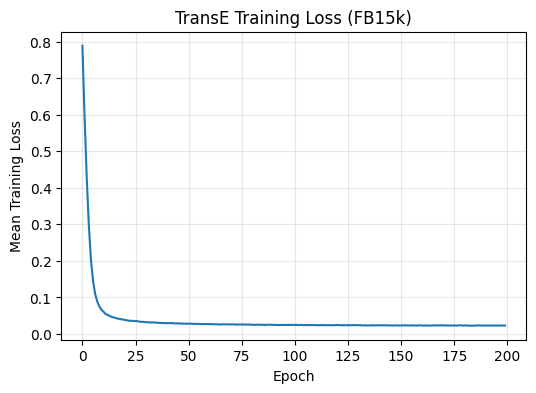

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Mean Training Loss")
plt.title("TransE Training Loss (FB15k)")
plt.grid(alpha=0.3)
plt.show()


## 8. Evaluation: Link Prediction (Raw / Filtered, Mean Rank, Hits@10)
1. 각 테스트 triple마다 head를 전체 엔티티로, tail을 전체 엔티티로 각각 교체
2. 거리 계산 → 오름차순 정렬 → 정답의 순위(rank) 기록
3. **filtered**: 정답을 제외한, train/valid/test에 실제로 존재하는 다른 참인 triple들을 후보에서 제거

In [9]:
@torch.no_grad()
def build_filter_sets(all_triples):
    """filtered 평가를 위해, (h, r) -> 참인 tail 집합 / (r, t) -> 참인 head 집합을 구축"""
    tails_given_hr = {}
    heads_given_rt = {}

    # tensor든 set/list든 상관없이 처리하도록 함
    if torch.is_tensor(all_triples):
        iterable = all_triples.tolist()
    else:
        iterable = all_triples  # set이나 list인 경우 그대로 iterate

    for h, r, t in iterable:
        
        tails_given_hr.setdefault((h, r), set()).add(t)
        heads_given_rt.setdefault((r, t), set()).add(h)
    return tails_given_hr, heads_given_rt

In [10]:
tails_given_hr, heads_given_rt = build_filter_sets(all_triples)

In [11]:
@torch.no_grad()
def evaluate(model, test_triples, n_entities, device, batch_size=64, hits_k=10, max_samples=None):
    model.eval()
    all_entities = torch.arange(n_entities, device=device)  # (n_entities,)

    ranks_raw, ranks_filt = [], []

    if not torch.is_tensor(test_triples):
        raise TypeError(f"test_triples must be a tensor, got {type(test_triples)}")

    triples = test_triples if max_samples is None else test_triples[:max_samples]

    for idx in range(0, len(triples), batch_size):
        chunk = triples[idx: idx + batch_size].to(device)  # (B, 3)
        B = chunk.size(0)

        h_col, r_col, t_col = chunk[:, 0], chunk[:, 1], chunk[:, 2]

        # ---------------- tail 예측: (h, r, ?) ----------------
        # (B, n_entities) 형태로 한 번에 계산
        h_rep = h_col.repeat_interleave(n_entities)          # (B*n_entities,)
        r_rep = r_col.repeat_interleave(n_entities)          # (B*n_entities,)
        e_rep = all_entities.repeat(B)                       # (B*n_entities,)

        d_tail = model.distance(h_rep, r_rep, e_rep).view(B, n_entities)  # (B, n_entities)

        true_d_tail = d_tail[torch.arange(B), t_col]  # (B,) 정답 tail의 거리
        rank_raw_tail = (d_tail < true_d_tail.unsqueeze(1)).sum(dim=1) + 1  # (B,)

        d_tail_filt = d_tail.clone()
        for i in range(B):
            h_i, r_i, t_i = h_col[i].item(), r_col[i].item(), t_col[i].item()
            true_tails = tails_given_hr.get((h_i, r_i), set()) - {t_i}
            if true_tails:
                d_tail_filt[i, list(true_tails)] = float("inf")
        rank_filt_tail = (d_tail_filt < d_tail_filt[torch.arange(B), t_col].unsqueeze(1)).sum(dim=1) + 1

        # ---------------- head 예측: (?, r, t) ----------------
        t_rep = t_col.repeat_interleave(n_entities)
        r_rep2 = r_col.repeat_interleave(n_entities)
        e_rep2 = all_entities.repeat(B)

        d_head = model.distance(e_rep2, r_rep2, t_rep).view(B, n_entities)  # (B, n_entities)

        true_d_head = d_head[torch.arange(B), h_col]
        rank_raw_head = (d_head < true_d_head.unsqueeze(1)).sum(dim=1) + 1

        d_head_filt = d_head.clone()
        for i in range(B):
            h_i, r_i, t_i = h_col[i].item(), r_col[i].item(), t_col[i].item()
            true_heads = heads_given_rt.get((r_i, t_i), set()) - {h_i}
            if true_heads:
                d_head_filt[i, list(true_heads)] = float("inf")
        rank_filt_head = (d_head_filt < d_head_filt[torch.arange(B), h_col].unsqueeze(1)).sum(dim=1) + 1

        ranks_raw.extend(rank_raw_tail.tolist())
        ranks_raw.extend(rank_raw_head.tolist())
        ranks_filt.extend(rank_filt_tail.tolist())
        ranks_filt.extend(rank_filt_head.tolist())

    ranks_raw = torch.tensor(ranks_raw, dtype=torch.float)
    ranks_filt = torch.tensor(ranks_filt, dtype=torch.float)

    def summarize(ranks):
        mr = ranks.mean().item()
        hits = (ranks <= hits_k).float().mean().item() * 100
        return mr, hits

    mr_raw, hits_raw = summarize(ranks_raw)
    mr_filt, hits_filt = summarize(ranks_filt)

    print(f"[RAW]      Mean Rank: {mr_raw:.4f} | Hits@{hits_k}: {hits_raw:.4f}")
    print(f"[FILTERED] Mean Rank: {mr_filt:.4f} | Hits@{hits_k}: {hits_filt:.4f}")

    return {
        "raw": {"mean_rank": mr_raw, "hits@10": hits_raw},
        "filtered": {"mean_rank": mr_filt, "hits@10": hits_filt}
    }

results = evaluate(model, test.to(device), n_ent, device, max_samples=500)

[RAW]      Mean Rank: 165.5510 | Hits@10: 37.8000
[FILTERED] Mean Rank: 88.9260 | Hits@10: 49.8000


## 9. (Optional) Overall Test set evaluation
위에서 샘플로 잘 동작하는 걸 확인했다면, `max_samples=None`으로 전체 test set을 평가 (GPU 권장)

In [12]:
results_full = evaluate(model, test.to(device), n_ent, device, max_samples=None)

[RAW]      Mean Rank: 227.8185 | Hits@10: 37.0546
[FILTERED] Mean Rank: 110.6206 | Hits@10: 49.3863


## 10. Save Model

In [13]:
torch.save({
    "entity_emb": model.entity_emb.detach().cpu(),
    "relation_emb": model.relation_emb.detach().cpu(),
    "ent2id": ent2id,
    "rel2id": rel2id,
    "config": {"k": K, "margin": MARGIN, "p_norm": P_NORM},
}, "TransE_fb15k.pt")

print("saved to TransE_fb15k.pt")


saved to TransE_fb15k.pt
